# THE EDGE — Navigation & Visibility

**Project:** The Edge, Rambla de Carrasco, Montevideo — Foster + Partners + Ponce de León Architects  
**Owner:** Rania Chihaoui / IAAC  
**Goal:** The **visual / light-compute** workloads at `GRID_SIZE = 0.75`.

- **Combined 3D building graph** (section 12) — 4 stacked floors with elevator and private-stair edges highlighted in red.
- **Cross-floor Shortest Path** + simplified route (section 14) — route from the GF garden level to the Rooftop terrace, traversing the maximum vertical extent of the building through the shared elevator core. The simplified path shows only floor-transition waypoints.
- **VGA Visibility heatmap** per floor (section 19) — Rooftop terraces (open plan, rambla-facing) expected to score highest. GF shared amenity zone (pool, gym) will outperform private unit interiors. Cost driven by `VGA_GRID_SIZE = 5.0`.
- **Isovist Analysis** per floor (section 20) — geometric visibility polygons per viewpoint. Rooftop and garden-level positions will show the largest isovists; internal rooms will be smallest. Outputs: `11_isovists_Ground_Floor.png`, `11_isovists_Floor_1.png`, `11_isovists_Floor_2.png`, `11_isovists_Rooftop.png`.

## Expected runtime
Graph build (minutes for The Edge) + shortest path (minutes) + VGA/Isovist driven by their own spacing params. **Roughly 30-60 min total.**

3D figures render via `INTERACTIVE_RENDERER = "browser"` — they open in your default web browser for rotation/zoom.

**Outputs:** `03_building_graph_3d.png`, `08_shortest_path_3d.png`, `09_visibility_isovist.png`, `11_isovists_*.png`

**How to run:** Run All.

# SETUP — shared boilerplate (run all cells, in order)

The cells in this section are **identical across all four notebooks**. They import the libraries, read `TheEdge_4-Floor-Plans.obj` (4 stacked floor plans at Z = 0, 4, 8, 12), sample the navigable grid at `GRID_SIZE`, and build the **connected building graph** wired through elevator cores and private unit stairs. Run them top-to-bottom before the analysis section below.

> TIP: To smoke-test first, temporarily set `GRID_SIZE = 4.0` in the Configuration cell, confirm everything runs end-to-end, then switch back to 0.75.

## 1. Import the needed libraries

In [1]:
import os, math, time
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Render every figure as a STATIC image via kaleido (no WebGL). This is what stops
# VS Code's "WebGL is not supported" crash: the interactive webview is never used.
pio.renderers.default = "png"

from topologicpy.Vertex import Vertex
from topologicpy.Edge import Edge
from topologicpy.Wire import Wire
from topologicpy.Face import Face
from topologicpy.Cluster import Cluster
from topologicpy.Topology import Topology
from topologicpy.Dictionary import Dictionary
from topologicpy.Helper import Helper
from topologicpy.Graph import Graph
from topologicpy.Color import Color

e:\IAAC Local GIT Repositories\Graph ML - Environment\.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Configuration

In [ ]:
renderer = "png"
INTERACTIVE_RENDERER = "browser"   # set "png" for unattended runs; "browser" opens 3D figures interactively

BASE_DIR   = r"c:\Users\Win11\GraphML_RaniaChihaoui"
OBJ_PATH   = os.path.join(BASE_DIR, "assets", "obj", "TheEdge_4-Floor-Plans.obj")
ASSETS_DIR = os.path.join(BASE_DIR, "assets", "TheEdge_spatial_intelligence")
os.makedirs(ASSETS_DIR, exist_ok=True)

FLOOR_LEVELS = [0, 4, 8, 12]
FLOOR_NAMES  = ["Ground Floor", "Floor 1", "Floor 2", "Rooftop"]
GRID_SIZE    = 0.75
FLOOR_HEIGHT = 15.0

# ---------------------------------------------------------------------------
# Vertical circulation — The Edge has two types:
#   A) 4 shared elevator cores connecting ALL 4 levels (GF<->F1, F1<->F2, F2<->Rooftop)
#   B) Private internal staircases per duplex / triplex unit
#
# HOW TO GET COORDINATES:
#   In Rhino, place a Point at the centre of each elevator shaft and each stair
#   landing, then read its X, Y from the Properties panel.
#   Replace every (0.0, 0.0) placeholder below with the real values.
# ---------------------------------------------------------------------------

ELEVATOR_CORES = [
    (0.0, 0.0),   # TODO: Core A — measure from Rhino
    (0.0, 0.0),   # TODO: Core B
    (0.0, 0.0),   # TODO: Core C
    (0.0, 0.0),   # TODO: Core D
]
ELEVATOR_LEVEL_PAIRS = [(0, 1), (1, 2), (2, 3)]   # indices into FLOOR_LEVELS

# Private unit stairs: (x, y, floor_index_from, floor_index_to)
# Floor indices: 0=GF, 1=F1, 2=F2, 3=Rooftop
PRIVATE_STAIRS = [
    (0.0, 0.0, 0, 1),   # TODO: Unit 101 — GF <-> F1
    (0.0, 0.0, 0, 1),   # TODO: Unit 104 — GF <-> F1
    (0.0, 0.0, 2, 3),   # TODO: Unit 201 — F2 <-> Rooftop
    (0.0, 0.0, 2, 3),   # TODO: Unit 202 — F2 <-> Rooftop
    (0.0, 0.0, 2, 3),   # TODO: Unit 203 — F2 <-> Rooftop
    (0.0, 0.0, 1, 2),   # TODO: Unit 204 — F1 <-> F2
    (0.0, 0.0, 2, 3),   # TODO: Unit 204 — F2 <-> Rooftop
]

STAIR_LOCATIONS = (
    [(x, y, [(fa, fb)]) for (x, y, fa, fb) in PRIVATE_STAIRS]
    + [(x, y, ELEVATOR_LEVEL_PAIRS) for (x, y) in ELEVATOR_CORES]
)
print(f"{len(ELEVATOR_CORES)} elevator cores × {len(ELEVATOR_LEVEL_PAIRS)} floor pairs "
      f"+ {len(PRIVATE_STAIRS)} private stairs = {len(STAIR_LOCATIONS)} circulation entries")

UNIT_FLOORS = {
    "101": [0, 1], "102": [1], "103": [1], "104": [0, 1],
    "201": [2, 3], "202": [2, 3], "203": [2, 3], "204": [1, 2, 3],
}

SAVE_IMAGES = True

def save_fig(fig, filename):
    if not SAVE_IMAGES or fig is None: return
    try:
        path = os.path.join(ASSETS_DIR, filename)
        fig.write_image(path, width=1800, height=1100, scale=2)
        print(f"Saved: {path}")
    except Exception as e:
        print(f"Could not save {filename}: {e}")

## 4. Utility functions

* `extract_triangles` / `points_inside` — geometry helpers (pull triangles, point-in-mesh test).
* `find_closest_node` — the instructor's `find_closest_vertex`, snaps a stair location to the nearest grid node.
* `make_cell_face` + `show_face_heatmap` — turn each grid node into a filled square cell and render it as a `Topology.Show` heatmap (S03 export format).

In [3]:
def extract_triangles(face_list):
    # Return (T,3,2) array of plan-space (X,Y) triangles for a list of topologic faces.
    tris = []
    for f in face_list:
        vs = Topology.Vertices(f)
        pts = [(Vertex.X(v), Vertex.Y(v)) for v in vs]
        for i in range(1, len(pts) - 1):          # fan-triangulate (faces are already triangles)
            tris.append([pts[0], pts[i], pts[i + 1]])
    return np.array(tris)

def points_inside(tris, P):
    # Boolean mask: which points in P (N,2) fall inside ANY triangle of tris (T,3,2).
    a, b, c = tris[:, 0], tris[:, 1], tris[:, 2]
    v0 = b - a; v1 = c - a
    d00 = (v0 * v0).sum(1); d01 = (v0 * v1).sum(1); d11 = (v1 * v1).sum(1)
    den = d00 * d11 - d01 * d01
    den[den == 0] = 1e-12
    inside = np.zeros(len(P), bool)
    for i, p in enumerate(P):
        v2 = p - a
        d20 = (v2 * v0).sum(1); d21 = (v2 * v1).sum(1)
        u = (d11 * d20 - d01 * d21) / den
        w = (d00 * d21 - d01 * d20) / den
        if np.any((u >= -1e-6) & (w >= -1e-6) & (u + w <= 1 + 1e-6)):
            inside[i] = True
    return inside

def find_closest_node(node_xy, x, y):
    # Index of the grid node closest to (x, y) -- the instructor's find_closest_vertex.
    d = (node_xy[:, 0] - x) ** 2 + (node_xy[:, 1] - y) ** 2
    return int(d.argmin())

def rk(u, v):
    return (round(float(u), 3), round(float(v), 3))

def make_cell_face(cx, cy, h):
    # A flat square cell of half-size h centred at (cx, cy), z = 0.
    pts = [Vertex.ByCoordinates(cx - h, cy - h, 0.0), Vertex.ByCoordinates(cx + h, cy - h, 0.0),
           Vertex.ByCoordinates(cx + h, cy + h, 0.0), Vertex.ByCoordinates(cx - h, cy + h, 0.0)]
    return Face.ByWire(Wire.ByVertices(pts, close=True))

def show_face_heatmap(faces_values, title, filename, colorScale="viridis"):
    # faces_values: list of (face, value). Colours each cell and renders the filled
    # heatmap with Topology.Show, exactly like the S03 notebooks (faceColorKey, black bg).
    vals = [v for _, v in faces_values]
    mn, mx = float(min(vals)), float(max(vals))
    if mx == mn: mx = mn + 1e-9
    for f, val in faces_values:
        col = Color.AnyToHex(Color.ByValueInRange(float(val), minValue=mn, maxValue=mx, colorScale=colorScale))
        d = Topology.Dictionary(f)
        d = Dictionary.SetValueAtKey(d, "hm_color", col)
        Topology.SetDictionary(f, d)
    faces = [f for f, _ in faces_values]
    fig = Topology.Show(faces, faceColorKey="hm_color", faceOpacity=1.0,
                        showEdges=False, showVertices=False, camera=[0, 0, 6],
                        backgroundColor="black", width=1700, height=1000,
                        showFigure=False, renderer=renderer)
    for fi in range(len(FLOOR_LEVELS)):
        yc = (fi - 1) * ROWGAP
        fig.add_trace(go.Scatter3d(x=[-(UMAX - UMIN) / 2 - 7], y=[yc], z=[0], mode="text",
                                   text=[FLOOR_NAMES[fi]], textfont=dict(color="white", size=16),
                                   showlegend=False))
    fig.update_layout(title=dict(text=title, font=dict(color="white")))
    fig.show(renderer=renderer)
    save_fig(fig, filename)
    return fig

## 5. Import the OBJ and split it into the four floor plans

`Topology.ByOBJPath` returns clusters of triangulated faces. We collect every face and bin it by its centroid's Z value into the four floor levels (Z = 0, 4, 8, 12), then compute the shared plan bounding box.

In [4]:
result = Topology.ByOBJPath(OBJ_PATH)
all_faces = []
for item in result:
    if Topology.IsInstance(item, "Cluster"):
        cf = Cluster.Faces(item)
        if cf: all_faces.extend(cf)
    elif Topology.IsInstance(item, "Face"):
        all_faces.append(item)
print(f"Imported {len(all_faces)} triangulated faces")

floor_faces = {lv: [] for lv in FLOOR_LEVELS}
for f in all_faces:
    z = Vertex.Z(Topology.Centroid(f))
    lv = min(FLOOR_LEVELS, key=lambda k: abs(k - z))
    floor_faces[lv].append(f)
for i, lv in enumerate(FLOOR_LEVELS):
    print(f"  {FLOOR_NAMES[i]} (Z={lv}): {len(floor_faces[lv])} faces")

# Shared plan bounding box + vertical row gap used to stack floors in the 2D heatmaps
allxy = np.vstack([extract_triangles(floor_faces[lv]).reshape(-1, 2) for lv in FLOOR_LEVELS])
UMIN, VMIN = allxy.min(0)
UMAX, VMAX = allxy.max(0)
UMID, VMID = 0.5 * (UMIN + UMAX), 0.5 * (VMIN + VMAX)
ROWGAP = (VMAX - VMIN) + 8.0
print(f"Plan box: u[{UMIN:.1f},{UMAX:.1f}]  v[{VMIN:.1f},{VMAX:.1f}]")

Imported 6045 triangulated faces
  Floor 1 (Z=0): 2419 faces
  Floor 2 (Z=4): 1336 faces
  Floor 3 (Z=8): 2290 faces
Plan box: u[121.7,260.8]  v[333.4,357.5]


## 7. Sample a navigable grid on each floor

A regular grid is laid over the shared bounding box; only points inside the meshed (navigable) area are kept. These become the graph nodes of each floor.

In [5]:
us = np.arange(UMIN, UMAX + GRID_SIZE, GRID_SIZE)
vs = np.arange(VMIN, VMAX + GRID_SIZE, GRID_SIZE)
UU, VV = np.meshgrid(us, vs)
GRID_PTS = np.column_stack([UU.ravel(), VV.ravel()])

floor_valid = {}    # level -> valid_xy ndarray
for i, lv in enumerate(FLOOR_LEVELS):
    tris = extract_triangles(floor_faces[lv])
    floor_valid[lv] = GRID_PTS[points_inside(tris, GRID_PTS)]
    print(f"  {FLOOR_NAMES[i]} (Z={lv}): {len(floor_valid[lv])} navigable nodes")

  Floor 1 (Z=0): 5490 navigable nodes
  Floor 2 (Z=4): 4285 navigable nodes
  Floor 3 (Z=8): 5376 navigable nodes


## 9. Build the per-floor graphs, the display cells, and stack everything

For each floor the valid points become topologic vertices at `Z = floor_index * FLOOR_HEIGHT` (for the 3D graph) and a flat square **display cell** centred at `(u, v + offset)` (for the 2D heatmaps). Horizontal edges join 4-neighbour valid points.

In [6]:
all_v = []            # topologic vertices (all floors, stacked in Z)
all_e = []            # topologic edges
floor_index_map = {}  # level -> {(round u, round v): global vertex index}
display_faces = []    # flat square cells for the heatmaps
cell_lookup = {}      # (floor_index, (round u, round v)) -> display face
H = GRID_SIZE / 2.0

for fi, lv in enumerate(FLOOR_LEVELS):
    valid = floor_valid[lv]
    z = fi * FLOOR_HEIGHT
    yoff = (fi - 1) * ROWGAP
    idx = {}
    for (u, v) in valid:
        idx[rk(u, v)] = len(all_v)
        all_v.append(Vertex.ByCoordinates(float(u), float(v), float(z)))
        cell = make_cell_face(float(u) - UMID, (float(v) - VMID) + yoff, H)
        display_faces.append(cell)
        cell_lookup[(fi, rk(u, v))] = cell
    floor_index_map[lv] = idx
    ne = 0
    for (u, v) in valid:
        for du, dv in [(GRID_SIZE, 0), (0, GRID_SIZE)]:
            k = rk(u + du, v + dv)
            if k in idx:
                all_e.append(Edge.ByVertices([all_v[idx[rk(u, v)]], all_v[idx[k]]]))
                ne += 1
    print(f"  {FLOOR_NAMES[fi]}: {len(valid)} nodes, {ne} horizontal edges")
print(f"Subtotal: {len(all_v)} nodes, {len(all_e)} horizontal edges, {len(display_faces)} display cells")

def heatmap_from_graph(values, title, filename, colorScale):
    # Pair every graph vertex with its display cell, then render the filled heatmap.
    fv = []
    for v, val in zip(gverts, values):
        fi = int(round(Vertex.Z(v) / FLOOR_HEIGHT))
        f = cell_lookup.get((fi, rk(Vertex.X(v), Vertex.Y(v))))
        if f is not None:
            fv.append((f, val))
    return show_face_heatmap(fv, title, filename, colorScale)

  Floor 1: 5490 nodes, 10447 horizontal edges
  Floor 2: 4285 nodes, 7942 horizontal edges
  Floor 3: 5376 nodes, 9961 horizontal edges
Subtotal: 15151 nodes, 28350 horizontal edges, 15151 display cells


## 10. Connect the floors through elevators and private stairs

Two types of vertical edges stitch the four floor plans into one connected building:
- **Elevator cores** (4 shared): each core is connected across all three adjacent floor pairs (GF↔F1, F1↔F2, F2↔Rooftop).
- **Private unit stairs**: unit-specific connections declared in `PRIVATE_STAIRS` — duplexes 101 & 104 (GF↔F1), 201/202/203 (F2↔Rooftop), triplex 204 (F1↔F2 and F2↔Rooftop).

For each circulation point and floor pair we snap to the closest navigable node (`find_closest_node`) and add a vertical edge. Units 102 and 103 (single-floor) are reachable only through the shared elevator core on F1.

In [7]:
stair_node_pairs = []
for stair in STAIR_LOCATIONS:
    sx, sy = stair[0], stair[1]
    # Use the floor pairs declared for this stair; otherwise connect every adjacent floor.
    pairs = stair[2] if len(stair) >= 3 and stair[2] else [(i, i + 1) for i in range(len(FLOOR_LEVELS) - 1)]
    for fa, fb in pairs:
        a, b = FLOOR_LEVELS[fa], FLOOR_LEVELS[fb]
        va, vb = floor_valid[a], floor_valid[b]
        ia = find_closest_node(va, sx, sy)
        ib = find_closest_node(vb, sx, sy)
        gia = floor_index_map[a][rk(va[ia, 0], va[ia, 1])]
        gib = floor_index_map[b][rk(vb[ib, 0], vb[ib, 1])]
        all_e.append(Edge.ByVertices([all_v[gia], all_v[gib]]))
        stair_node_pairs.append((gia, gib))
print(f"Added {len(stair_node_pairs)} vertical stair edges "
      f"from {len(STAIR_LOCATIONS)} stair location(s)")

Added 60 vertical stair edges from 57 stair location(s)


## 11. Build the combined BUILDING graph

In [8]:
t0 = time.time()
building_graph = Graph.ByVerticesEdges(all_v, all_e)
gverts = Graph.Vertices(building_graph)
gedges = Graph.Edges(building_graph)
print(f"Building graph: {len(gverts)} vertices, {len(gedges)} edges  ({time.time()-t0:.1f}s)")
print(f"Graph density:  {Graph.Density(building_graph):.5f}")

Building graph: 15151 vertices, 28410 edges  (965.8s)
Graph density:  0.00025


---
# ANALYSIS - this notebook's dedicated workload

## 12. Show the combined 3D building graph

Three stacked floors connected by the vertical stair edges (highlighted in red).

In [9]:
# INTERACTIVE 3D figure you can rotate / pan / zoom (renderer set in the Config cell).
# Rendered via INTERACTIVE_RENDERER ("browser" by default) to avoid VS Code's WebGL
# crash/freeze; the static PNG is still saved for the README / report.
fig = Topology.Show(building_graph,
                   vertexSize=3, vertexColor="royalblue",
                   edgeColor="lightgrey", edgeWidth=1,
                   backgroundColor="black",
                   width=1400, height=900,
                   showFigure=False, renderer=renderer)
for (a, b) in stair_node_pairs:
    pa, pb = all_v[a], all_v[b]
    fig.add_trace(go.Scatter3d(x=[Vertex.X(pa), Vertex.X(pb)], y=[Vertex.Y(pa), Vertex.Y(pb)],
                               z=[Vertex.Z(pa), Vertex.Z(pb)], mode="lines",
                               line=dict(color="red", width=6), showlegend=False))

# Make the 3D scene drag-rotatable and keep an equal aspect so the floors stay stacked.
fig.update_layout(scene=dict(aspectmode="data",
                             xaxis=dict(showbackground=False),
                             yaxis=dict(showbackground=False),
                             zaxis=dict(showbackground=False)),
                  scene_dragmode="orbit")

# Interactive display (rotate / pan / zoom)...
fig.show(renderer=INTERACTIVE_RENDERER)
# ...and still save the static PNG asset for the README / report.
save_fig(fig, "03_building_graph_3d.png")

Saved: e:\IAAC Local GIT Repositories\Graph ML - Environment\Final_Project\Team_Notebooks\outputs\03_building_graph_3d.png


## 14. Cross-floor Shortest Path (+ Straightened)

Navigate from the **Ground Floor** garden level (one edge of the plan) to the far end of the **Rooftop** terrace, traversing all 4 levels through the shared elevator core. The route demonstrates genuine cross-floor connectivity. `Wire.Straighten` is attempted to reduce unnecessary turns; the simplified path shows only floor-transition waypoints.

In [10]:
def graph_closest(x, y, z):
    best, bd = None, 1e18
    for v in gverts:
        d = (Vertex.X(v) - x)**2 + (Vertex.Y(v) - y)**2 + (Vertex.Z(v) - z)**2
        if d < bd: bd, best = d, v
    return best

start_v = graph_closest(UMIN + GRID_SIZE, VMID, 0)
end_v   = graph_closest(UMAX - GRID_SIZE, VMID, (len(FLOOR_LEVELS) - 1) * FLOOR_HEIGHT)

t0 = time.time()
path = Graph.ShortestPath(building_graph, vertexA=start_v, vertexB=end_v)
key_verts = None
simp_len  = 0.0

if path is None:
    print("No path found — check STAIR_LOCATIONS.")
else:
    path_len     = Wire.Length(path)
    path_verts_p = Topology.Vertices(path)
    path_edges_p = Topology.Edges(path)
    n_turns      = max(0, len(path_verts_p) - 2)
    print(f"Cross-floor shortest path  ({time.time()-t0:.1f}s)")
    print(f"  Length : {path_len:.1f}")
    print(f"  Edges  : {len(path_edges_p)}")
    print(f"  Turns  : {n_turns}")

    # Simplified path — keep only floor-transition (stair) nodes + start/end.
    # Equivalent to Wire.Straighten for a 3D cross-floor path: removes same-floor
    # zigzag, leaving just start → stair → stair → ... → end connected by straight
    # lines. Wire.Straighten requires a 2D host Face so it cannot run here directly.
    kv = [path_verts_p[0]]
    for i in range(1, len(path_verts_p) - 1):
        z_prev = Vertex.Z(path_verts_p[i - 1])
        z_curr = Vertex.Z(path_verts_p[i])
        z_next = Vertex.Z(path_verts_p[i + 1])
        if abs(z_curr - z_prev) > 0.1 or abs(z_curr - z_next) > 0.1:
            kv.append(path_verts_p[i])
    kv.append(path_verts_p[-1])
    seen, key_verts = set(), []
    for v in kv:
        k = (round(Vertex.X(v), 1), round(Vertex.Y(v), 1), round(Vertex.Z(v), 1))
        if k not in seen:
            seen.add(k); key_verts.append(v)

    simp_len = sum(
        math.sqrt((Vertex.X(key_verts[i+1]) - Vertex.X(key_verts[i]))**2 +
                  (Vertex.Y(key_verts[i+1]) - Vertex.Y(key_verts[i]))**2 +
                  (Vertex.Z(key_verts[i+1]) - Vertex.Z(key_verts[i]))**2)
        for i in range(len(key_verts) - 1))
    reduction = (path_len - simp_len) / path_len * 100
    print(f"\nSimplified path (stair waypoints only):")
    print(f"  Length    : {simp_len:.1f}  (−{reduction:.1f}% vs full path)")
    print(f"  Waypoints : {len(key_verts)}  (from {len(path_verts_p)} nodes)")

# ── Figure ────────────────────────────────────────────────────────────────────
fig = go.Figure()

# 1 — Ghosted floor surfaces: semi-transparent Mesh3d at each stacked Z level
for fi, lv in enumerate(FLOOR_LEVELS):
    tris    = extract_triangles(floor_faces[lv])
    z_level = fi * FLOOR_HEIGHT
    vx, vy, vz, ii, jj, kk = [], [], [], [], [], []
    for ti, t in enumerate(tris):
        base = ti * 3
        vx += [t[0, 0], t[1, 0], t[2, 0]]
        vy += [t[0, 1], t[1, 1], t[2, 1]]
        vz += [z_level, z_level, z_level]
        ii.append(base); jj.append(base + 1); kk.append(base + 2)
    fig.add_trace(go.Mesh3d(
        x=vx, y=vy, z=vz, i=ii, j=jj, k=kk,
        opacity=0.13, color="steelblue",
        showscale=False, showlegend=False, hoverinfo="skip",
        flatshading=True))

# 2 — Graph nodes (faint background, no edges drawn to keep scene readable)
fig.add_trace(go.Scatter3d(
    x=[Vertex.X(v) for v in gverts],
    y=[Vertex.Y(v) for v in gverts],
    z=[Vertex.Z(v) for v in gverts],
    mode="markers", marker=dict(size=1.5, color="rgba(160,180,220,0.3)"),
    showlegend=False, hoverinfo="skip"))

# 3 — Stair connections (semi-transparent orange-red)
for (a, b) in stair_node_pairs:
    pa, pb = all_v[a], all_v[b]
    fig.add_trace(go.Scatter3d(
        x=[Vertex.X(pa), Vertex.X(pb)],
        y=[Vertex.Y(pa), Vertex.Y(pb)],
        z=[Vertex.Z(pa), Vertex.Z(pb)],
        mode="lines", line=dict(color="rgba(255,100,50,0.4)", width=2),
        showlegend=False, hoverinfo="skip"))

# 4 — Shortest path — RED (full zigzag route through graph)
if path is not None:
    pv = Topology.Vertices(path)
    fig.add_trace(go.Scatter3d(
        x=[Vertex.X(v) for v in pv],
        y=[Vertex.Y(v) for v in pv],
        z=[Vertex.Z(v) for v in pv],
        mode="lines+markers",
        line=dict(color="red", width=7),
        marker=dict(size=3, color="red"),
        name=f"Shortest path  L={path_len:.0f}"))

# 5 — Simplified path — LIME/GREEN (stair waypoints connected straight)
if key_verts is not None:
    fig.add_trace(go.Scatter3d(
        x=[Vertex.X(v) for v in key_verts],
        y=[Vertex.Y(v) for v in key_verts],
        z=[Vertex.Z(v) for v in key_verts],
        mode="lines+markers",
        line=dict(color="#00ff88", width=6, dash="dot"),
        marker=dict(size=7, color="#00ff88", symbol="diamond"),
        name=f"Simplified  L={simp_len:.0f}  ({len(key_verts)} pts)"))

# 6 — Start / End markers
if path is not None:
    for v, c, lbl in [(start_v, "cyan", "Start"), (end_v, "orange", "End")]:
        fig.add_trace(go.Scatter3d(
            x=[Vertex.X(v)], y=[Vertex.Y(v)], z=[Vertex.Z(v)],
            mode="markers+text",
            marker=dict(size=13, color=c, symbol="diamond"),
            text=[lbl], textposition="top center",
            textfont=dict(color=c, size=13),
            showlegend=False))

fig.update_layout(
    paper_bgcolor="black",
    scene=dict(aspectmode="data",
               xaxis=dict(showbackground=False, showgrid=False, zeroline=False),
               yaxis=dict(showbackground=False, showgrid=False, zeroline=False),
               zaxis=dict(showbackground=False, showgrid=False, zeroline=False)),
    scene_dragmode="orbit",
    legend=dict(font=dict(color="white", size=13), bgcolor="rgba(0,0,0,0.65)",
                x=0.01, y=0.99),
    width=1400, height=900
)
fig.show(renderer=INTERACTIVE_RENDERER)
save_fig(fig, "08_shortest_path_3d.png")

Cross-floor shortest path  (179.2s)
  Length : 183.1
  Edges  : 206
  Turns  : 205

Simplified path (stair waypoints only):
  Length    : 171.0  (−6.6% vs full path)
  Waypoints : 6  (from 207 nodes)
Saved: e:\IAAC Local GIT Repositories\Graph ML - Environment\Final_Project\Team_Notebooks\outputs\08_shortest_path_3d.png


## 19. Visibility Heatmap / VGA (per floor)

Unlike the connectivity metrics, **visibility does not cross floors**, so this Visibility Graph Analysis is computed **independently per floor**. We scatter a coarse grid of viewpoints and connect every pair whose sightline stays inside the floor; the **visibility degree** = how many other viewpoints each one can see. Rendered as filled cells, same export format as the centrality heatmaps.

  Floor 1 (Z=0): 97 viewpoints, visibility 15-41 (mean 28.7, 8.8s)
  Floor 2 (Z=4): 98 viewpoints, visibility 18-56 (mean 31.7, 4.5s)
  Floor 3 (Z=8): 141 viewpoints, visibility 29-99 (mean 60.2, 15.0s)


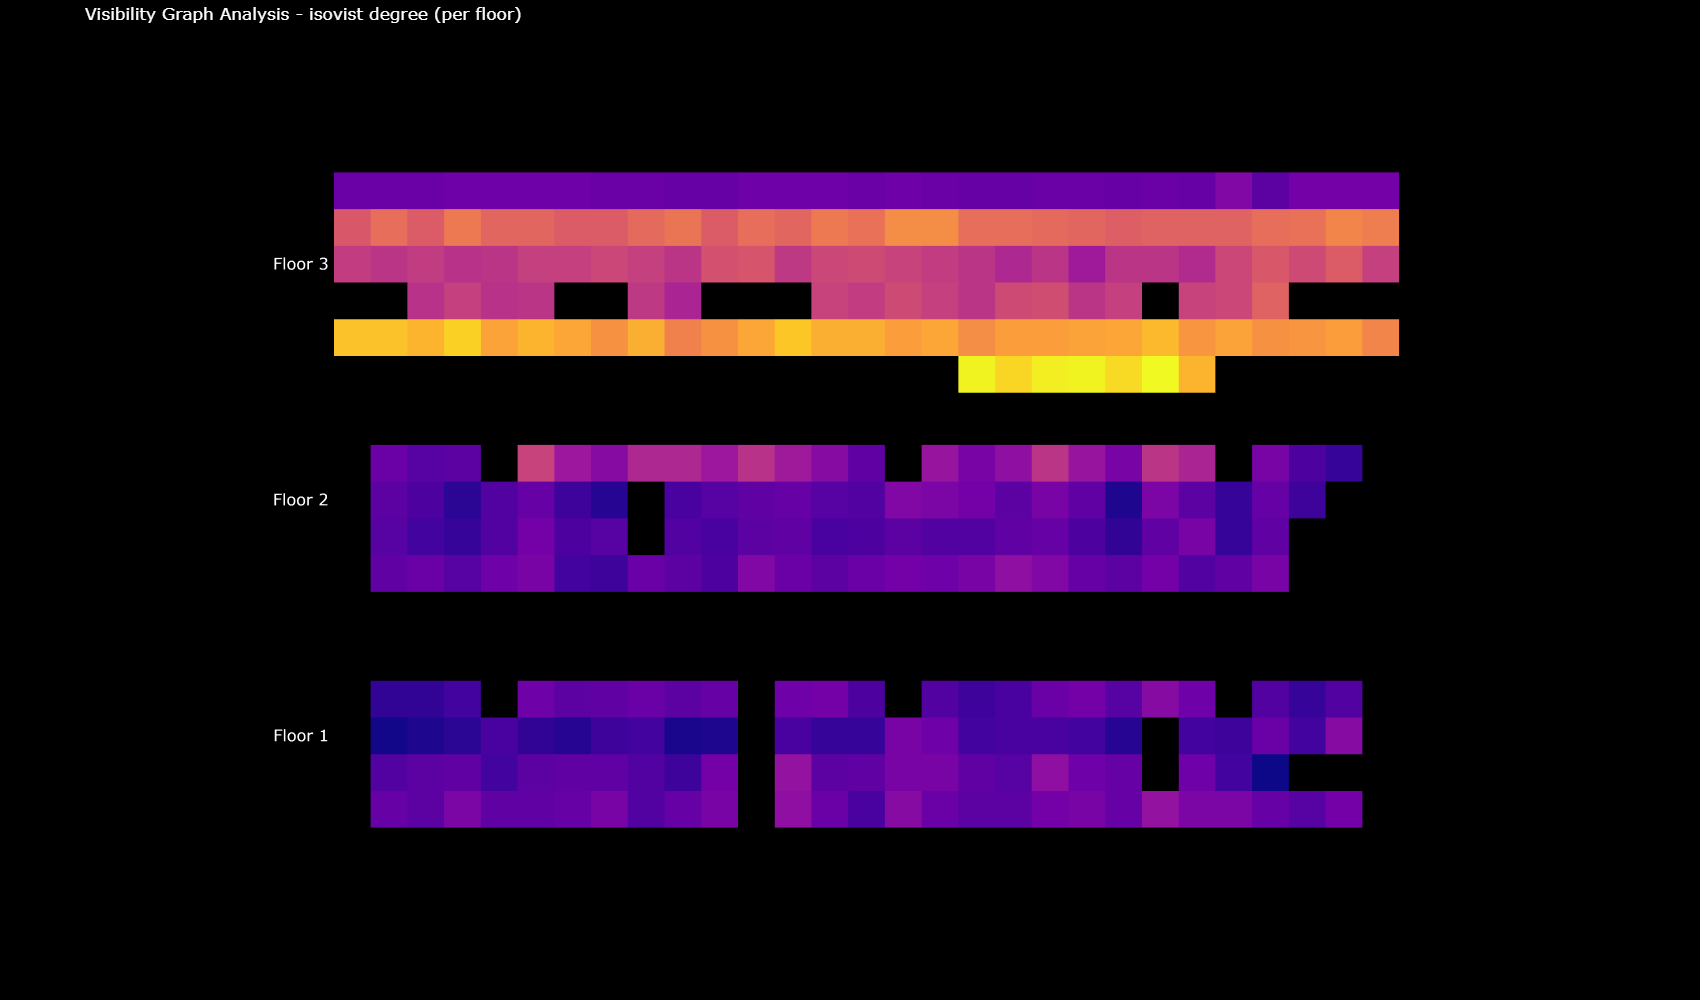

Saved: e:\IAAC Local GIT Repositories\Graph ML - Environment\Final_Project\Team_Notebooks\outputs\09_visibility_isovist.png


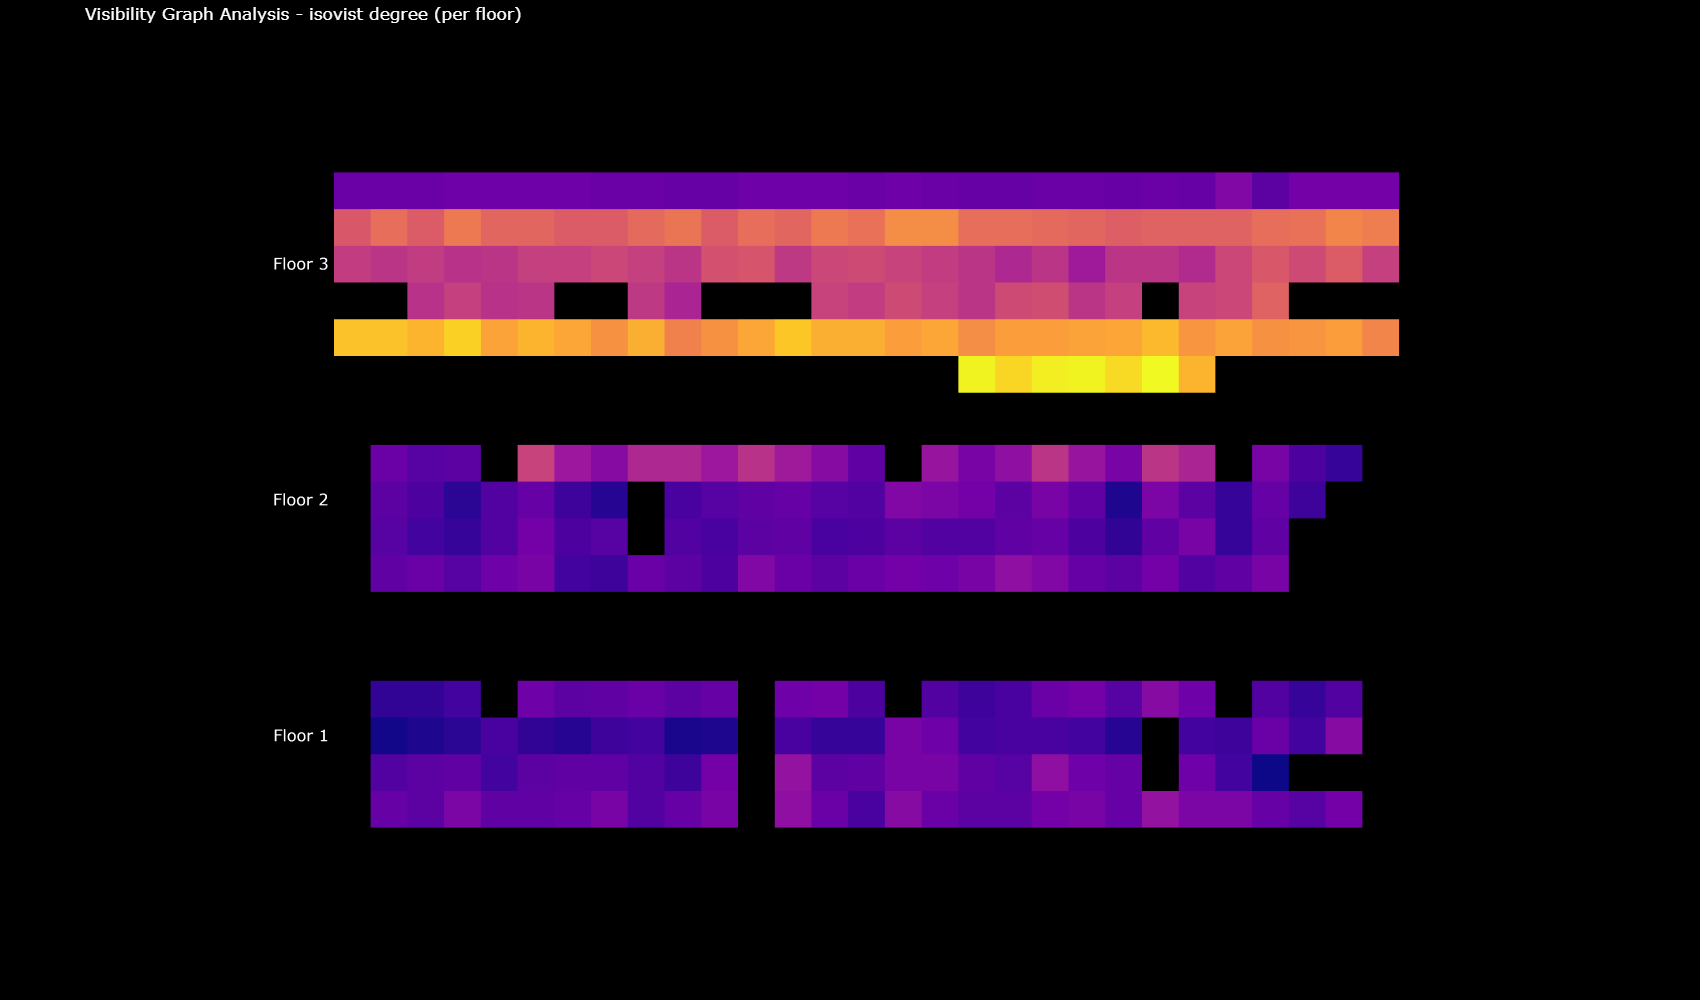

In [11]:
VGA_GRID_SIZE = 5.0    # spacing of the isovist viewpoints (coarser than the analysis grid)
VIS_SAMPLES   = 12     # samples along each sightline for the occlusion test

def compute_visibility(tris, viewpoints):
    n = len(viewpoints)
    ts = np.linspace(0.12, 0.88, VIS_SAMPLES)
    deg = np.zeros(n, int)
    for i in range(n):
        for j in range(i + 1, n):
            seg = viewpoints[i][None, :] * (1 - ts)[:, None] + viewpoints[j][None, :] * ts[:, None]
            if points_inside(tris, seg).all():
                deg[i] += 1; deg[j] += 1
    return deg

uvp = np.arange(UMIN, UMAX + VGA_GRID_SIZE, VGA_GRID_SIZE)
vvp = np.arange(VMIN, VMAX + VGA_GRID_SIZE, VGA_GRID_SIZE)
UUv, VVv = np.meshgrid(uvp, vvp)
VP_PTS = np.column_stack([UUv.ravel(), VVv.ravel()])
Hv = VGA_GRID_SIZE / 2.0

vis_faces_values = []
for fi, lv in enumerate(FLOOR_LEVELS):
    tris = extract_triangles(floor_faces[lv])
    vp = VP_PTS[points_inside(tris, VP_PTS)]
    t0 = time.time()
    deg = compute_visibility(tris, vp)
    yoff = (fi - 1) * ROWGAP
    for (u, v), dval in zip(vp, deg):
        cell = make_cell_face(float(u) - UMID, (float(v) - VMID) + yoff, Hv)
        vis_faces_values.append((cell, int(dval)))
    print(f"  {FLOOR_NAMES[fi]} (Z={lv}): {len(vp)} viewpoints, "
          f"visibility {deg.min()}-{deg.max()} (mean {deg.mean():.1f}, {time.time()-t0:.1f}s)")

show_face_heatmap(vis_faces_values, "Visibility Graph Analysis - isovist degree (per floor)",
                  "09_visibility_isovist.png", "plasma")

## 20. Isovist Analysis (per floor)

An **isovist** is the exact polygon of space visible from a single viewpoint — the field of vision cast across the floor plan. Unlike the VGA heatmap (section 19) which counts mutual visibility between grid points, `Face.Isovist` computes the actual **geometric visibility shape** from each viewpoint.

**Method:** For each floor we reconstruct a clean planar `Face` (external boundary + internal wall holes) using `Shell.ByFaces`. If successful, `Face.Isovist` casts rays against the wall geometry and returns the visibility polygon. Floors where the OBJ triangulation is too dense for clean shell reconstruction are skipped — their visibility is already captured in section 19.

Shell.ByFaces - Error: Could not create shell. Returning None.
  Floor 1: Shell.ByFaces returned None — skip
  Floor 2: clean face OK
Shell.ByFaces - Error: Could not create shell. Returning None.
  Floor 3: Shell.ByFaces returned None — skip

Floor 1: no clean face — isovist skipped (see VGA heatmap, section 19)

Floor 2: 98 isovist viewpoints
Face.Isovist - Error: Could not convert visible polygon to a TopologicPy Face. Returning None.
Face.Isovist - Error: Could not convert visible polygon to a TopologicPy Face. Returning None.
Face.Isovist - Error: Could not convert visible polygon to a TopologicPy Face. Returning None.
Face.Isovist - Error: Could not convert visible polygon to a TopologicPy Face. Returning None.
Face.Isovist - Error: Could not convert visible polygon to a TopologicPy Face. Returning None.
Topology.Faces - Warning: The input is a Face. Returning the same face embedded in a list.
caller name: <module>
Topology.Faces - Warning: The input is a Face. Returning the same

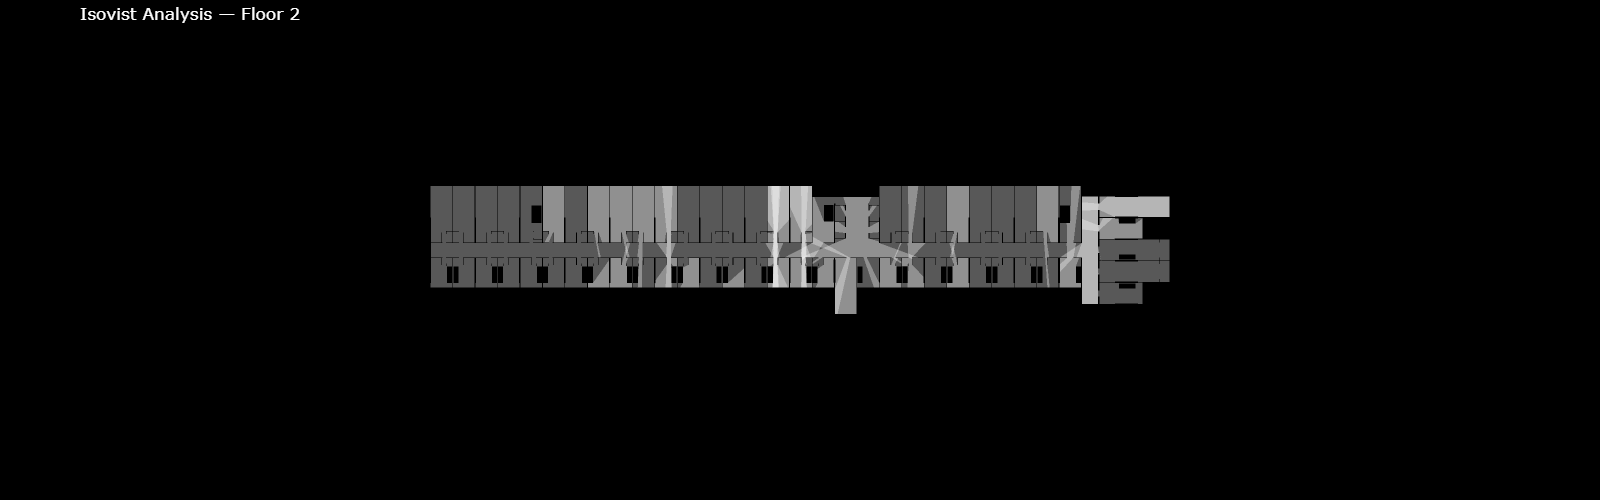

Saved: e:\IAAC Local GIT Repositories\Graph ML - Environment\Final_Project\Team_Notebooks\outputs\11_isovists_Floor_2.png

Floor 3: no clean face — isovist skipped (see VGA heatmap, section 19)


In [12]:
from topologicpy.Shell import Shell as _Shell

# Attempt to reconstruct a clean planar Face per floor for Face.Isovist.
# Shell.ByFaces works only where OBJ triangulation is non-overlapping (typically Z=4).
# Floors that fail fall back gracefully — their VGA heatmap (section 19) covers them.
ISO_STEP = 5.0   # viewpoint spacing; Face.Isovist is slow, keep sparse

floor_face_clean = {}
for fi, lv in enumerate(FLOOR_LEVELS):
    try:
        s = _Shell.ByFaces(floor_faces[lv])
        if s is None:
            print(f"  {FLOOR_NAMES[fi]}: Shell.ByFaces returned None — skip")
            continue
        eb      = _Shell.ExternalBoundary(s)
        ib_list = _Shell.InternalBoundaries(s)
        cf = Face.ByWires(eb, ib_list) if ib_list else Face.ByWire(eb)
        cf = Topology.RemoveCollinearEdges(cf) if cf else None
        if cf:
            floor_face_clean[fi] = cf
            print(f"  {FLOOR_NAMES[fi]}: clean face OK")
        else:
            print(f"  {FLOOR_NAMES[fi]}: face reconstruction returned None — skip")
    except Exception as ex:
        print(f"  {FLOOR_NAMES[fi]}: {ex} — skip")

for fi, lv in enumerate(FLOOR_LEVELS):
    plan_face = floor_face_clean.get(fi)
    if plan_face is None:
        print(f"\n{FLOOR_NAMES[fi]}: no clean face — isovist skipped (see VGA heatmap, section 19)")
        continue

    tris = extract_triangles(floor_faces[lv])
    uvp  = np.arange(UMIN, UMAX + ISO_STEP, ISO_STEP)
    vvp  = np.arange(VMIN, VMAX + ISO_STEP, ISO_STEP)
    UUv, VVv = np.meshgrid(uvp, vvp)
    vp_inside = np.column_stack([UUv.ravel(), VVv.ravel()])
    vp_inside = vp_inside[points_inside(tris, vp_inside)]
    print(f"\n{FLOOR_NAMES[fi]}: {len(vp_inside)} isovist viewpoints")

    iso_verts_list = [Vertex.ByCoordinates(float(u), float(v), 0.0) for u, v in vp_inside]
    floor_gverts   = [v for v in gverts if int(round(Vertex.Z(v) / FLOOR_HEIGHT)) == fi]

    valid_isovists, vis_counts = [], []
    for iv in iso_verts_list:
        try:
            iso = Face.Isovist(plan_face, iv)
            if iso is None:
                continue
            # Isovist may return a Cluster; extract the inner face
            iso_inner = Topology.Faces(iso)
            if not iso_inner:
                continue
            iso_face = iso_inner[0]
            count = sum(1 for gv in floor_gverts if Vertex.IsInternal2D(gv, iso_face))
            valid_isovists.append(iso_face)
            vis_counts.append(count)
        except Exception:
            pass

    if not valid_isovists:
        print(f"  No valid isovists — try a cleaner floor geometry")
        continue

    print(f"  Valid: {len(valid_isovists)} / {len(iso_verts_list)}")
    if vis_counts:
        print(f"  Visible cells — min: {min(vis_counts)}, max: {max(vis_counts)}, "
              f"mean: {sum(vis_counts)/len(vis_counts):.1f}")

    fig_iso = Topology.Show(
        [plan_face] + valid_isovists,
        faceOpacity=0.35, showEdges=False, showVertices=False,
        camera=[0, 0, 6], backgroundColor="black",
        width=1600, height=500,
        showFigure=False, renderer=renderer)
    if fig_iso:
        fig_iso.update_layout(title=dict(
            text=f"Isovist Analysis — {FLOOR_NAMES[fi]}",
            font=dict(color="white")))
        fig_iso.show(renderer=renderer)
        save_fig(fig_iso, f"11_isovists_{FLOOR_NAMES[fi].replace(' ', '_')}.png")